<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/KNN_Creditos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tarea 7: Detección de K-vecinos mediante créditos devueltos (si/no) utilizando algoritmo para aprendizaje supervisado KNN.

* Juan Diego Ancarani
* 19/5/2026

Datos trabajados: https://ucao365-my.sharepoint.com/:x:/g/personal/rialantonio_uca_edu_ar/IQCr1VvK0kRnSq5L-H_kLh4bAcG7qTV4kMeQoryEuYUPO4g?e=L55BCm


Narrativa: personas pidieron un crédito financiero el mes pasado, se conoce:

* edad.
* crédito que deben abonar.
* si cumplio/no cumplio.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier


datos_clientes = pd.read_csv('creditos(in).csv')
datos_clientes.head()

,edad,credito,cumplio
0,18,363112,0
1,19,477965,1
2,20,239072,0
3,22,195265,0
4,22,482174,0


In [ ]:
cumplidores = datos_clientes[datos_clientes['cumplio'] == 1]
no_cumplidores = datos_clientes[datos_clientes['cumplio'] == 0]

display(cumplidores.head(5))
display(no_cumplidores.head(5))

,edad,credito,cumplio
1,19,477965,1
6,23,583565,1
7,24,100000,1
8,24,199272,1
13,25,195341,1


,edad,credito,cumplio
0,18,363112,0
2,20,239072,0
3,22,195265,0
4,22,482174,0
5,23,468815,0


Visualizacion → cumplidores vs no cumplidores

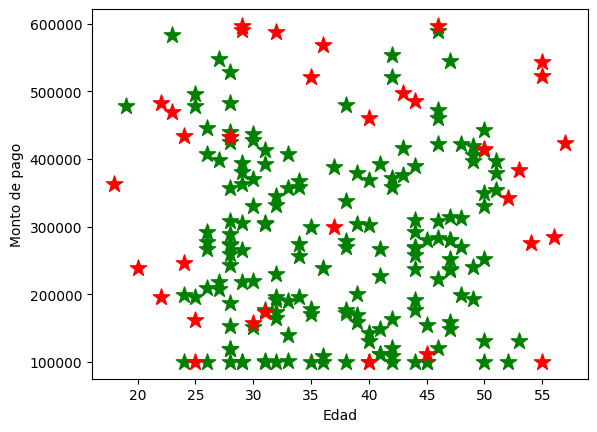

Personas que cumplieron con la devolución →  167
Personas que no cumplieron con la devolución →  33


In [ ]:
plt.scatter(cumplidores['edad'], cumplidores['credito'],
            marker = '*', s = 150, color = 'green', label = 'Cumplio y pago (clase:1)')

plt.scatter(no_cumplidores['edad'], no_cumplidores['credito'],
            marker = '*', s = 150, color = 'red', label = 'No cumplio el pago (clase:0)')


plt.ylabel('Monto de pago')
plt.xlabel('Edad')
plt.show()

conteo_cumplidores = len(cumplidores.index)
conteo_no_cumplidores = len(no_cumplidores.index)

print('Personas que cumplieron con la devolución → ', conteo_cumplidores)
print('Personas que no cumplieron con la devolución → ', conteo_no_cumplidores)

Generar escalado de varibales.

¿Por que? → calcular matematicamente la distancia entre variables para predecir la ubicacion geometrica de una variable nueva de entrada.

In [ ]:
datos = datos_clientes[['edad', 'credito']]
clase = datos_clientes[['cumplio']]

escalador = preprocessing.MinMaxScaler()
datos_escalados = escalador.fit_transform(datos)
datos_escalados


array([[0.        , 0.52964444],
       [0.02564103, 0.76084353],
       [0.05128205, 0.27995193],
       [0.1025641 , 0.19176844],
       [0.1025641 , 0.76931624],
       [0.12820513, 0.74242458],
       [0.12820513, 0.97341632],
       [0.15384615, 0.        ],
       [0.15384615, 0.19983453],
       [0.15384615, 0.29429053],
       [0.15384615, 0.67122276],
       [0.17948718, 0.        ],
       [0.17948718, 0.12374716],
       [0.17948718, 0.19192143],
       [0.17948718, 0.76130249],
       [0.17948718, 0.79673129],
       [0.20512821, 0.        ],
       [0.20512821, 0.21862589],
       [0.20512821, 0.33577846],
       [0.20512821, 0.35571521],
       [0.20512821, 0.38628463],
       [0.20512821, 0.61926119],
       [0.20512821, 0.69480706],
       [0.23076923, 0.21664509],
       [0.23076923, 0.23805134],
       [0.23076923, 0.60140789],
       [0.23076923, 0.90058196],
       [0.25641026, 0.        ],
       [0.25641026, 0.03816245],
       [0.25641026, 0.03904616],
       [0.

In [ ]:
clasificador = KNeighborsClassifier(n_neighbors = 5, metric = 'manhattan')
clasificador.fit(datos_escalados, clase)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='manhattan')

## Nuevos solicitantes (clasificador)

Clase de acreditador que pertenece German:  [1]
Probabilidad de que pertenezca a la clase:  [[0. 1.]]
Clase de acreditador que pertenece Roman:  [0]
Probabilidad de que pertenezca a la clase:  [[0.8 0.2]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


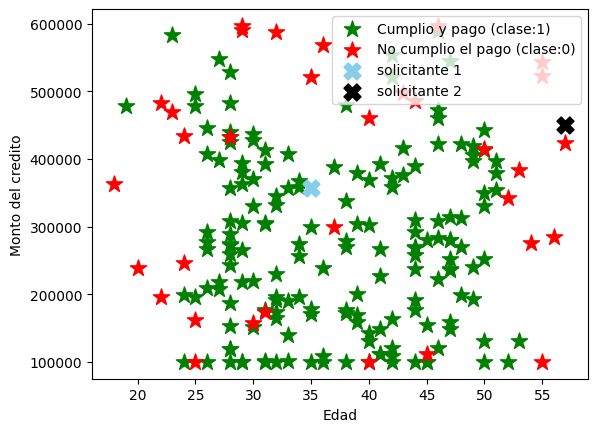

In [ ]:
import warnings
warnings.filterwarnings('ignore', message = 'X no tiene un nombre valido para la feature')

#registrar a un nuevo solicitante → el algoritmo decide si (pago/no pago)

nombre = 'german'
edad_solic1 = 35
monto_solic1 = 356700

nombre = 'roman'
edad_solic2= 57
monto_solic2 = 450000

#Escalar datos
solicitante1 = escalador.transform([[edad_solic1, monto_solic1]])
solicitante2 = escalador.transform([[edad_solic2, monto_solic2]])


#calcular clase y probabilidades
print('Clase de acreditador que pertenece German: ', clasificador.predict(solicitante1))
print('Probabilidad de que pertenezca a la clase: ',
      clasificador.predict_proba(solicitante1))

print('Clase de acreditador que pertenece Roman: ', clasificador.predict(solicitante2))
print('Probabilidad de que pertenezca a la clase: ',
      clasificador.predict_proba(solicitante2))

#Graficar ubicación de este solicitante

plt.scatter(cumplidores['edad'], cumplidores['credito'],
            marker = '*', s = 150, color = 'green', label = 'Cumplio y pago (clase:1)')

plt.scatter(no_cumplidores['edad'], no_cumplidores['credito'],
            marker = '*', s = 150, color = 'red', label = 'No cumplio el pago (clase:0)')


plt.scatter(edad_solic1, monto_solic1,
marker = 'X', s = 150, color = 'skyblue', label = 'solicitante 1')

plt.scatter(edad_solic2, monto_solic2,
marker = 'X', s = 150, color = 'black', label = 'solicitante 2')


plt.ylabel('Monto del credito')
plt.xlabel('Edad')
plt.legend()
plt.show()


Logíca *‘dime con quién andas y te diré quien eres’.*


Las personas más jóvenes [18-23] años y más mayores [54-60] años suelen ser las que deben el crédito (no pagaron). Si solicitamos a una persona con tal edad y un monto que se ajuste a la dispersión vista en la distribución, es posible que dicha persona aun adeude el crédito.